# Diabetes Baseline Model – Decision Tree Training & Evaluation

This notebook performs:
- Loading processed diabetes data
- Train/Test split
- Decision Tree classifier training
- Evaluation: accuracy, precision, recall, F1
- Saving evaluation metrics and training plots


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os


In [45]:
PROCESSED_DATA_PATH = "../data/diabetes_processed.csv"

df = pd.read_csv(PROCESSED_DATA_PATH)

print("Processed data shape:", df.shape)
df.head()


Processed data shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,4.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [46]:
TARGET_COLUMN = "Outcome"
FEATURES = [col for col in df.columns if col != TARGET_COLUMN]

X = df[FEATURES]
y = df[TARGET_COLUMN]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (614, 8) Test shape: (154, 8)


In [ ]:
# Best hyperparameters
# max_depth = 5
# min_samples_split = 10
# min_samples_leaf = 5
# -----------Underfitting params: tree is shallow poor to capture patterns-----------
# max_depth = 1
# min_samples_split = 50
# min_samples_leaf = 20
# -----------Overfitting params tree is deep so good on training accuracy but poor test accuracy -----------
# max_depth = None  
# min_samples_split = 2
# min_samples_leaf = 1
# ---------------------------------------best---------------------
max_depth = 5  
min_samples_split = 5
min_samples_leaf = 5




print(f"Using max_depth={max_depth}, min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf}")


Using max_depth=5, min_samples_split=5, min_samples_leaf=5


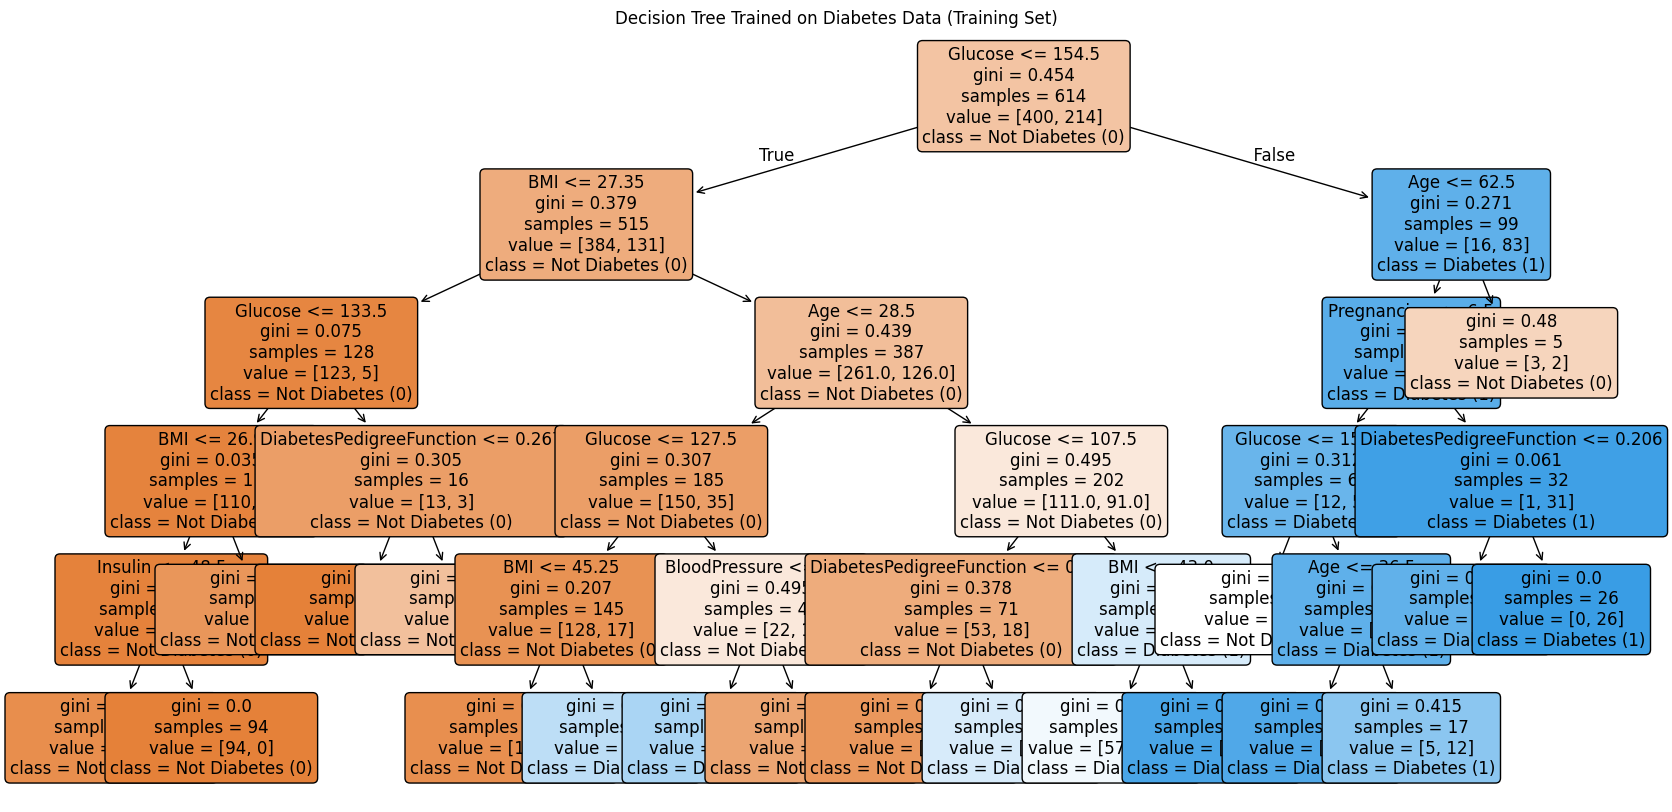

In [48]:

# Train Decision Tree
model = DecisionTreeClassifier(
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# --- Visualize the Decision Tree ---
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=FEATURES,
    class_names=["Not Diabetes (0)", "Diabetes (1)"],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree Trained on Diabetes Data (Training Set)")
plt.show()


In [49]:
# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Train Accuracy: 0.8013
Test Accuracy: 0.7727
Precision: 0.6508
Recall: 0.7593
F1 Score: 0.7009


In [50]:
RESULTS_DIR = "../results/metrics"
os.makedirs(RESULTS_DIR, exist_ok=True)

metrics_file = os.path.join(RESULTS_DIR, "evaluation_results.csv")

metrics_df = pd.DataFrame([{
    "train_accuracy": train_acc,
    "test_accuracy": test_acc,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf
}])

# Append if file exists, else create
if os.path.exists(metrics_file):
    metrics_df.to_csv(metrics_file, mode='a', header=False, index=False)
else:
    metrics_df.to_csv(metrics_file, mode='w', header=True, index=False)
print(f"Evaluation metrics saved to {metrics_file}")


Evaluation metrics saved to ../results/metrics/evaluation_results.csv


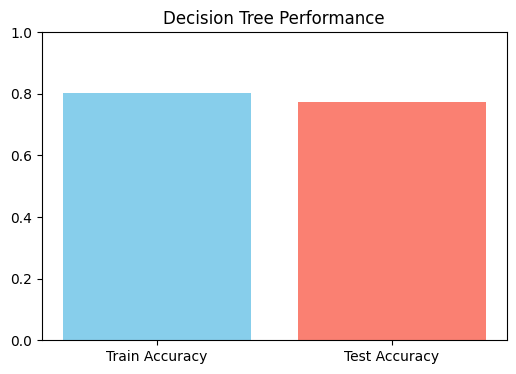

Training plot saved as: max5_split5_leaf5.png


In [51]:
FIGURES_DIR = "../results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.figure(figsize=(6,4))
plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc], color=['skyblue','salmon'])
plt.ylim(0,1)
plt.title("Decision Tree Performance")

# Save file with hyperparameter info
plot_filename = f"max{max_depth}_split{min_samples_split}_leaf{min_samples_leaf}.png"
plt.savefig(os.path.join(FIGURES_DIR, plot_filename))
plt.show()

print(f"Training plot saved as: {plot_filename}")
